In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

torch.manual_seed(42)

In [2]:
use_cuda = True
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if (use_cuda and torch.cuda.is_available()) else "cpu")
print(f"Using device: {device}")

CUDA available: True
Using device: cuda


In [ ]:
import kagglehub
import shutil
import os

#running this cell only in collab (use t4 gpu as runtime type :) 
# Download dataset
path = kagglehub.dataset_download("sachinkumar413/diabetic-retinopathy-dataset")
print("Downloaded to:", path)

# Copy to writable Colab directory
destination = "/content/dataset"

shutil.copytree(path, destination, dirs_exist_ok=True)
print("Copied to:", destination)


for root, dirs, files in os.walk(destination):
    print("Current path:", root)
    print("Folders:", dirs)
    print("------")
    break  


# Step 6: Remove unwanted folders
folders_to_remove = ["Mild DR", "Moderate DR", "Proliferate DR"]

for folder in folders_to_remove:
    folder_path = os.path.join(destination, folder)

    if os.path.exists(folder_path):
        shutil.rmtree(folder_path)
        print(f"Removed: {folder_path}")
    else:
        print(f"Folder not found: {folder_path}")

Using Colab cache for faster access to the 'diabetic-retinopathy-dataset' dataset.
Downloaded to: /kaggle/input/diabetic-retinopathy-dataset
Copied to: /content/dataset
Current path: /content/dataset
Folders: ['Proliferate DR', 'Severe DR', 'Healthy', 'Moderate DR', 'Mild DR']
------
Removed: /content/dataset/Mild DR
Removed: /content/dataset/Moderate DR
Removed: /content/dataset/Proliferate DR


In [4]:
complete_path = "./dataset/.complete"

if os.path.exists(complete_path):
    shutil.rmtree(complete_path)
    print("Removed .complete folder")

In [5]:
# For loading the Diabetic Retinopathy Dataset

transforms_base = transforms.Compose([transforms.ToTensor()])

# full_dataset[i] is a a tuple of (image tensor, class index)
full_dataset = torchvision.datasets.DatasetFolder(root="./dataset", loader=torchvision.datasets.folder.default_loader, transform=transforms_base, extensions=[".png"])

In [6]:
print("Classes:", full_dataset.class_to_idx)
print("Total dataset size:", len(full_dataset))

healthy = 0
severe = 0
for data in full_dataset:
    if data[1] == 0:
        healthy += 1
    elif data[1] == 1:
        severe += 1
print("Total 'Healthy' samples:", healthy)
print("Total 'Severe' samples:", severe)

Classes: {'Healthy': 0, 'Severe DR': 1}
Total dataset size: 1190
Total 'Healthy' samples: 1000
Total 'Severe' samples: 190


In [7]:
'''
Training-Test-Validation Split
Train dataset: 80% of 'Healthy' + 80% of 'Severe'
Test dataset: 10% of 'Healthy' + 10% of 'Severe'
Validation dataset: 10% of 'Healthy' + 10% of 'Severe'
'''

targets = full_dataset.targets
train_indices = []
test_indices = []
validation_indices = []

for c in range(len(full_dataset.classes)):
    class_indices = [i for i, t in enumerate(targets) if t==c]
    torch.manual_seed(42)
    perm = torch.randperm(len(class_indices)).tolist()
    if c == 0:
        r = healthy
    else:
        r = severe
    a = int(r*0.8)
    b = int(r*0.9)
    train_indices.extend([class_indices[p] for p in perm[:a]])
    test_indices.extend([class_indices[p] for p in perm[a:b]])
    validation_indices.extend([class_indices[p] for p in perm[b:r]])

train_dataset = torch.utils.data.Subset(full_dataset, train_indices)
test_dataset = torch.utils.data.Subset(full_dataset, test_indices)
validation_dataset = torch.utils.data.Subset(full_dataset, validation_indices)

In [8]:
# Dataloaders

batch_size = 32
train_dataloader = DataLoader(train_dataset, batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size, shuffle=False)
validation_dataloader = DataLoader(validation_dataset, batch_size, shuffle=False)

In [9]:
class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()

        # Two Conv2d layers with ReLU
        self.conv = nn.Sequential(nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                                  nn.ReLU(),
                                  nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
                                  nn.ReLU()
                                  )
    def forward(self, x):
        return self.conv(x)


In [10]:
class EncoderBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()

        # Encoder: Conv block followed by MaxPool to downsample
        self.conv = ConvBlock(in_c, out_c)
        self.pool = nn.Sequential(
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

    def forward(self, x):
        # skip connection output before pooling
        s = self.conv(x)
        p = self.pool(s)
        return s, p


In [11]:
class DecoderBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        # Decoder: ConvTranspose2d to upsample (deconvolution), then Conv block
        self.up = nn.Sequential(
            nn.ConvTranspose2d(in_c, out_c, kernel_size=2, stride=2)
        )
        # After upsampling, concatenate skip connection by doubbling then conv
        self.conv = ConvBlock(out_c * 2, out_c)

    def forward(self, x, skip):
        #first upsample, then concatenate skip connection then conv
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        x = self.conv(x)
        return x


In [12]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder which are successive Conv+Pool blocks, increasing channels
        # compressing spatial size
        self.e1 = EncoderBlock(3, 32)
        self.e2 = EncoderBlock(32, 64)
        self.e3 = EncoderBlock(64, 128)

        # Bottleneck is the deepest compressed representation
        self.bottleneck = nn.Sequential(nn.Conv2d(128, 256, kernel_size=3, padding=1),
                                        nn.ReLU(),
                                        nn.Conv2d(256, 256, kernel_size=3, padding=1),
                                        nn.ReLU())


        # Decoder which are  successive ConvTranspose+Conv blocks, decreasing channels
        # expanding spatial size
        self.d1 = DecoderBlock(256, 128)
        self.d2 = DecoderBlock(128, 64)
        self.d3 = DecoderBlock(64, 32)

        self.out = nn.Sequential(nn.Conv2d(32, 1, kernel_size=1))

    def forward(self, x):

        #encoder pass
        s1, p1 = self.e1(x)
        s2, p2 = self.e2(p1)
        s3, p3 = self.e3(p2)

        # Bottleneck
        b = self.bottleneck(p3)

        # Decoder pass
        d1 = self.d1(b, s3)
        d2 = self.d2(d1, s2)
        d3 = self.d3(d2, s1)

        # Output
        out = self.out(d3)

        return d3


In [13]:
class UNetClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.unet = UNet()

        self.pool = nn.AdaptiveAvgPool2d(1)
        #2 classes as ooutput
        self.fc = nn.Sequential(nn.Linear(32, 2))

    def forward(self, x):
        x = self.unet(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [14]:
model = UNetClassifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),weight_decay = 1e-5)

In [15]:
loss_list = []
num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    running_loss = 0

    for images, labels in train_dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_dataloader)
    loss_list.append(epoch_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")

Epoch [1/20], Loss: 0.5095
Epoch [2/20], Loss: 0.4464
Epoch [3/20], Loss: 0.4440
Epoch [4/20], Loss: 0.4393
Epoch [5/20], Loss: 0.4099
Epoch [6/20], Loss: 0.3095
Epoch [7/20], Loss: 0.2806
Epoch [8/20], Loss: 0.2780
Epoch [9/20], Loss: 0.2772
Epoch [10/20], Loss: 0.2783
Epoch [11/20], Loss: 0.2654
Epoch [12/20], Loss: 0.2601
Epoch [13/20], Loss: 0.2642
Epoch [14/20], Loss: 0.2599
Epoch [15/20], Loss: 0.2493
Epoch [16/20], Loss: 0.2495
Epoch [17/20], Loss: 0.2735
Epoch [18/20], Loss: 0.2969
Epoch [19/20], Loss: 0.2605
Epoch [20/20], Loss: 0.2597


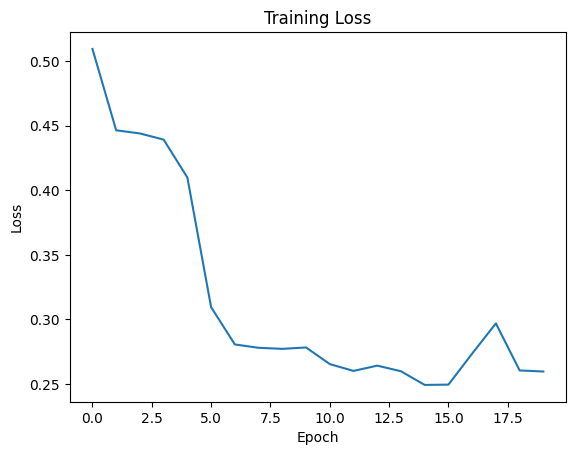

In [16]:
plt.plot(loss_list)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

In [19]:
def evaluate(dataloader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

val_acc = evaluate(validation_dataloader)
print(f"Validation Accuracy: {val_acc:.2f}%")

Validation Accuracy: 84.03%
